# Pick any image based dataset from the list, implement the preprocessing and justify the preprocessing steps.

In [1]:
import os
import cv2
import numpy as np

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from skimage.feature import hog
from skimage.color import rgb2gray

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

DATASET_PATH = "dataset"      # root folder containing class subfolders
IMAGE_SIZE = (128, 128)       # resize all images to this size
AUGMENT = True                # set False if you don't want augmentation
AUG_PER_IMAGE = 2             # how many augmented versions per image

In [2]:

# ---------------------------------------------------------
# Define preprocessing transforms (Torch)
# ---------------------------------------------------------

augmentation_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

base_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

# ---------------------------------------------------------
# Load and preprocess dataset
# ---------------------------------------------------------

images = []
labels = []

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d)) and not d.startswith('.')
])
label_encoder = LabelEncoder()
label_encoder.fit(classes)

print("Classes found:", classes)

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    print(f"Processing class: {class_name}")

    for filename in tqdm(os.listdir(class_path)):
        img_path = os.path.join(class_path, filename)

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Base preprocessing (resize + normalization)
        tensor_img = base_transform(img)
        images.append(tensor_img.numpy())
        labels.append(class_name)

        # Data augmentation
        if AUGMENT:
            for _ in range(AUG_PER_IMAGE):
                aug_img = augmentation_transforms(img)
                images.append(aug_img.numpy())
                labels.append(class_name)

# Convert to arrays
X = np.array(images)
y = label_encoder.transform(labels)

print("Preprocessing complete!")
print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", label_encoder.classes_)


Classes found: ['hatchback', 'motorcycle', 'pickup', 'sedan', 'suv']
Processing class: hatchback


  0%|          | 0/181 [00:00<?, ?it/s]

100%|██████████| 181/181 [00:00<00:00, 454.73it/s]


Processing class: motorcycle


100%|██████████| 122/122 [00:00<00:00, 410.22it/s]


...

Processing class: sedan


100%|██████████| 400/400 [00:00<00:00, 453.73it/s]


Processing class: suv


100%|██████████| 129/129 [00:00<00:00, 427.94it/s]


Preprocessing complete!
Dataset shape: (3930, 3, 128, 128)
Labels shape: (3930,)
Classes: ['hatchback' 'motorcycle' 'pickup' 'sedan' 'suv']


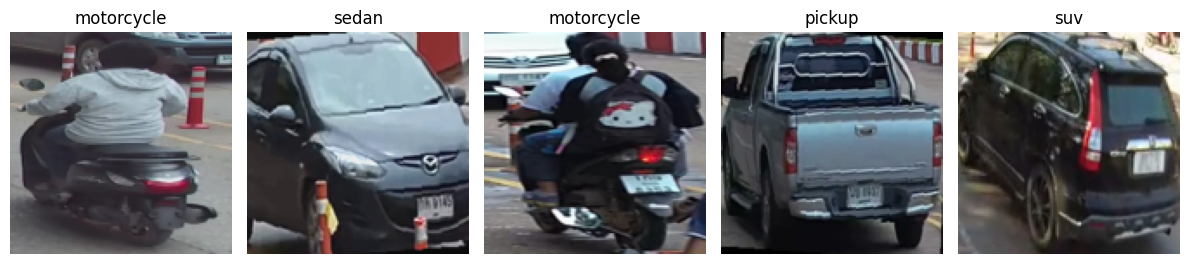

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(X, y, label_encoder, num=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num):
        idx = np.random.randint(0, len(X))
        img = X[idx]

        # Convert from (C, H, W) → (H, W, C)
        img = np.transpose(img, (1, 2, 0))

        label = label_encoder.inverse_transform([y[idx]])[0]
        
        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Display 5 images
show_images(X, y, label_encoder, num=5)


# Extract features and justify the methods used

In [4]:
def extract_hog_features(X):
    """
    X: numpy array of shape (N, C, H, W) or (N, H, W, C)
    Returns: HOG feature matrix of shape (N, num_features)
    """
    hog_features = []

    print("Extracting HOG features...")

    for i in tqdm(range(len(X))):

        img = X[i]

        # Convert from (C, H, W) -> (H, W, C) if needed
        if img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        # Convert image to grayscale because HOG works on single channel
        gray = rgb2gray(img)

        # Extract HOG descriptor
        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )

        hog_features.append(features)

    return np.array(hog_features)

In [5]:
X_hog = extract_hog_features(X)

print("HOG feature matrix shape:", X_hog.shape)

Extracting HOG features...


100%|██████████| 3930/3930 [00:07<00:00, 530.26it/s]


HOG feature matrix shape: (3930, 8100)


# Select features and justify the methods used.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_hog_scaled = scaler.fit_transform(X_hog)

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=150)   # Choose number based on variance
X_pca = pca.fit_transform(X_hog_scaled)

print("Reduced feature shape:", X_pca.shape)


Reduced feature shape: (3930, 150)


# Implement (using the selected features) one basic machine learning algorithm for classification and justify your choice 

In [ ]:
# Implement SVM with RBF kernel here